# Student Grade Predictor
## Multivariate Linear Regression

This notebook predicts a student's final grade (G3) on a 0–100 scale using the UCI Student Performance dataset (`student-por.csv`).

**Algorithm:** Ordinary Least Squares (Normal Equation) + Gradient Descent  
**Features:** All 30 variables in the dataset  
**Target:** G3 — final period grade (converted from 0–20 to 0–100)

## Section 1 — Imports

In [ ]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Section 2 — Load Real Data

Reads `student-por.csv` (semicolon-separated) and returns the encoded feature matrix `X`, target grades `y`, and feature names.

> **Make sure `student-por.csv` is in the same folder as this notebook before running!**

In [ ]:
JOBS      = ["teacher", "health", "services", "at_home"]  # 'other' = baseline
REASONS   = ["home", "reputation", "course"]               # 'other' = baseline
GUARDIANS = ["mother", "father"]                            # 'other' = baseline

def load_csv(filepath):
    rows = []
    with open(filepath, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f, delimiter=";")
        for row in reader:
            rows.append(row)

    raw = [
        (r["school"], r["sex"], int(r["age"]), r["address"],
         r["famsize"], r["Pstatus"], int(r["Medu"]), int(r["Fedu"]),
         r["Mjob"], r["Fjob"], r["reason"], r["guardian"],
         int(r["traveltime"]), int(r["studytime"]), int(r["failures"]),
         r["schoolsup"], r["famsup"], r["paid"], r["activities"],
         r["nursery"], r["higher"], r["internet"], r["romantic"],
         int(r["famrel"]), int(r["freetime"]), int(r["goout"]),
         int(r["Dalc"]), int(r["Walc"]), int(r["health"]),
         int(r["absences"]), float(r["G1"]), float(r["G2"]))
        for r in rows
    ]
    y = np.array([float(r["G3"]) * 5 for r in rows])  # convert 0-20 to 0-100
    X, feature_names = encode_features(raw)
    return X, y, feature_names

## Section 3 — Feature Encoding

Converts text categories into numbers so the math can work:
- **Binary** (e.g. school, sex) → 1 or 0
- **Numeric** (e.g. age, Medu) → kept as-is
- **Nominal** (e.g. Mjob, reason) → one-hot encoded (one column per category)

In [ ]:
def encode_features(raw):
    rows = []
    for (school, sex, age, address, famsize, pstatus, Medu, Fedu,
         Mjob, Fjob, reason, guardian, traveltime, studytime, failures,
         schoolsup, famsup, paid, activities, nursery, higher, internet,
         romantic, famrel, freetime, goout, Dalc, Walc, health,
         absences, G1, G2) in raw:

        row = [
            1.0 if school  == "GP"  else 0.0,
            1.0 if sex     == "F"   else 0.0,
            float(age),
            1.0 if address == "U"   else 0.0,
            1.0 if famsize == "GT3" else 0.0,
            1.0 if pstatus == "T"   else 0.0,
            float(Medu),
            float(Fedu),
        ]
        for j in JOBS:
            row.append(1.0 if Mjob == j else 0.0)
        for j in JOBS:
            row.append(1.0 if Fjob == j else 0.0)
        for res in REASONS:
            row.append(1.0 if reason == res else 0.0)
        for g in GUARDIANS:
            row.append(1.0 if guardian == g else 0.0)
        row += [float(traveltime), float(studytime), float(failures)]
        for val in [schoolsup, famsup, paid, activities,
                    nursery, higher, internet, romantic]:
            row.append(1.0 if val == "yes" else 0.0)
        row += [
            float(famrel), float(freetime), float(goout),
            float(Dalc), float(Walc), float(health),
            float(absences), float(G1) * 5, float(G2) * 5,
        ]
        rows.append(row)

    feature_names = (
        ["school_GP", "sex_F", "age", "address_U", "famsize_GT3", "Pstatus_T", "Medu", "Fedu"]
        + [f"Mjob_{j}" for j in JOBS]
        + [f"Fjob_{j}" for j in JOBS]
        + [f"reason_{r}" for r in REASONS]
        + [f"guardian_{g}" for g in GUARDIANS]
        + ["traveltime", "studytime", "failures"]
        + ["schoolsup", "famsup", "paid", "activities",
           "nursery", "higher", "internet", "romantic"]
        + ["famrel", "freetime", "goout", "Dalc", "Walc", "health", "absences", "G1", "G2"]
    )
    return np.array(rows, dtype=float), feature_names

## Section 4 — Pre-processing

Three helpers:
1. **train_test_split** — splits data into 80% train / 20% test
2. **standardize** — Z-score normalization so no feature dominates
3. **add_bias** — adds a column of 1s for the intercept term

In [ ]:
def train_test_split(X, y, test_ratio=0.2, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(y))
    cut = int(len(y) * (1 - test_ratio))
    tr, te = idx[:cut], idx[cut:]
    return X[tr], X[te], y[tr], y[te]

def standardize(X_train, X_test):
    mu    = X_train.mean(axis=0)
    sigma = X_train.std(axis=0)
    sigma[sigma == 0] = 1
    return (X_train - mu) / sigma, (X_test - mu) / sigma, mu, sigma

def add_bias(X):
    return np.hstack([np.ones((len(X), 1)), X])

**Standardization** ensures that all features are on the same scale.

Without standardization:
- Variables with larger values (like absences) would dominate
- Gradient descent would perform poorly

It improves stability and convergence speed.

## Section 5 — Models

The core of the project — two ways to solve Linear Regression:

**Normal Equation (OLS):** Solves directly with `w = (XᵀX)⁻¹Xᵀy`  
**Gradient Descent:** Iteratively adjusts weights to minimize MSE loss

In [ ]:
def fit_normal_equation(X, y):
    """ w = (XᵀX)⁻¹ Xᵀy """
    return np.linalg.pinv(X.T @ X) @ X.T @ y

def fit_gradient_descent(X, y, lr=0.05, n_epochs=1000):
    """
    Batch gradient descent:
      w <- w - lr * (1/n) * X^T(Xw - y)
    """
    n, p = X.shape
    w, losses = np.zeros(p), []
    for _ in range(n_epochs):
        resid  = X @ w - y
        w     -= lr * (X.T @ resid) / n
        losses.append(float(np.mean(resid ** 2)))
    return w, losses

def predict(X, w):
    return X @ w

In [ ]:
def ridge_regression(X, y, lam):
    n = X.shape[1]
    I = np.eye(n)
    return np.linalg.inv(X.T @ X + lam * I) @ X.T @ y

We applied **multiple linear regression techniques** to model the relationship between student features and final grade (G3). The dataset was first preprocessed by encoding categorical variables and standardizing numerical features. 

We then split the data into training and testing sets to evaluate model performance. Three regression approaches were used:

- Ordinary Least Squares (Normal Equation)
- Gradient Descent
- Ridge Regression (L2 Regularization)

These methods allowed us to compare different optimization techniques and evaluate how regularization impacts model performance and overfitting.

## Section 6 — Metrics

Two numbers to evaluate how good our predictions are:
- **MSE** — average squared error (lower = better)
- **R²** — how much of the grade variation the model explains (closer to 1 = better)

In [ ]:
def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return float(1 - ss_res / ss_tot)

## Section 7 — Plots

Three visualizations:
1. **Predicted vs Actual** — how close our predictions are
2. **Loss Curve** — gradient descent converging over 1000 epochs
3. **Feature Importance** — which variables matter most
4. **Learning Rate Comparison** - different learning rates affect convergence
5. **Residual Plot** - difference between predicted and actual
6. **Correlation Heatmap** - how each feature is correlated with the final grade
7. **Predicted vs Actual** - predicted grades to actual grades

In [ ]:
def plot_predictions(y_true, y_pred_ols, y_pred_gd):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Predicted vs Actual Final Grade (G3, scale 0-100)", fontsize=13, fontweight="bold")
    for ax, y_pred, label, color in zip(
        axes,
        [y_pred_ols, y_pred_gd],
        ["Normal Equation (OLS)", "Gradient Descent"],
        ["steelblue", "tomato"],
    ):
        ax.scatter(y_true, y_pred, alpha=0.6, color=color, edgecolors="white", s=60)
        lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
        ax.plot([lo, hi], [lo, hi], "k--", lw=1.2, label="Perfect fit")
        ax.set_xlabel("Actual G3"); ax.set_ylabel("Predicted G3")
        ax.set_title(f"{label}  |  R² = {r2(y_true, y_pred):.4f}")
        ax.legend()
    plt.tight_layout()
    plt.show()

def plot_loss_curve(losses):
    plt.figure(figsize=(7, 4))
    plt.plot(losses, color="tomato", lw=1.5)
    plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
    plt.title("Gradient Descent - Training Loss Curve")
    plt.tight_layout()
    plt.show()

def plot_coefficients(w_ols, feature_names):
    coefs = w_ols[1:]
    idx   = np.argsort(np.abs(coefs))[::-1]
    names, vals = [feature_names[i] for i in idx], coefs[idx]
    colors = ["steelblue" if v >= 0 else "tomato" for v in vals]
    plt.figure(figsize=(10, 8))
    plt.barh(names[::-1], vals[::-1], color=colors[::-1])
    plt.axvline(0, color="black", lw=0.8)
    plt.xlabel("Coefficient (standardised features)")
    plt.title("Feature Importance - OLS Coefficients")
    plt.tight_layout()
    plt.show()

def plot_learning_rates(X_tr_b, y_tr, lrs, n_epochs=200):
    plt.figure()
    
    for lr in lrs:
        _, losses = fit_gradient_descent(X_tr_b, y_tr, lr=lr, n_epochs=n_epochs)
        plt.plot(losses, label=f"lr={lr}")
    
    plt.legend()
    plt.title("Learning Rate Comparison")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

def plot_residuals(y_true, y_pred):
    residuals = y_true - y_pred
    
    plt.figure()
    plt.scatter(y_pred, residuals)
    plt.axhline(0)
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    plt.show()

def plot_correlation_heatmap(filepath):
    df = pd.read_csv(filepath, sep=";")

    y = df["G3"]
    X = df.drop("G3", axis=1)

    X = pd.get_dummies(X, drop_first=True)

    df = pd.concat([X, y], axis=1)
    corr = df.corr()

    top_corr = corr[["G3"]].sort_values(by="G3", ascending=False)

    plt.figure(figsize=(6, 10))
    sns.heatmap(top_corr, 
                annot=True, 
                cmap="coolwarm", 
                center=0,
                fmt=".2f")

    plt.title("Correlation with Final Grade (G3)")
    plt.tight_layout()
    plt.show()

def plot_predicted_vs_actual(y_true, y_pred):
    plt.figure()
    plt.scatter(y_true, y_pred)
    
    # diagonal reference line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val])
    
    plt.xlabel("Actual Grades")
    plt.ylabel("Predicted Grades")
    plt.title("Predicted vs Actual Grades")
    plt.show()


## Section 8 — Run Everything

Loads the data, trains both models, prints results, and shows all plots.

In [ ]:
# Load real data
X, y, feature_names = load_csv("student-por.csv")

# Split & scale
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_ratio=0.2)
X_tr_s, X_te_s, mu, sigma = standardize(X_tr, X_te)
X_tr_b = add_bias(X_tr_s)
X_te_b = add_bias(X_te_s)

# Fit models
w_ols        = fit_normal_equation(X_tr_b, y_tr)
w_gd, losses = fit_gradient_descent(X_tr_b, y_tr, lr=0.05, n_epochs=1000)

# Predict
y_pred_ols = predict(X_te_b, w_ols)
y_pred_gd  = predict(X_te_b, w_gd)

# Results
print("=" * 50)
print("  STUDENT GRADE PREDICTOR - RESULTS")
print("=" * 50)
for label, w, yp in [
    ("Normal Equation (OLS)", w_ols, y_pred_ols),
    ("Gradient Descent",      w_gd,  y_pred_gd),
]:
    print(f"\n> {label}")
    print(f"  MSE : {mse(y_te, yp):.4f}")
    print(f"  R2  : {r2(y_te, yp):.4f}")

print("\n> OLS Coefficients")
print(f"  {'intercept':25s}: {w_ols[0]:.4f}")
for name, coef in zip(feature_names, w_ols[1:]):
    print(f"  {name:25s}: {coef:.4f}")

  STUDENT GRADE PREDICTOR - RESULTS

> Normal Equation (OLS)
  MSE : 52.7032
  R2  : 0.7445

> Gradient Descent
  MSE : 52.6814
  R2  : 0.7446

> OLS Coefficients
  intercept                : 59.4798
  school_GP                : 0.6953
  sex_F                    : 0.2258
  age                      : 0.3264
  address_U                : 0.2772
  famsize_GT3              : 0.0154
  Pstatus_T                : -0.2443
  Medu                     : -0.7570
  Fedu                     : 0.3648
  Mjob_teacher             : 0.3929
  Mjob_health              : 0.4372
  Mjob_services            : 0.4669
  Mjob_at_home             : 0.2383
  Fjob_teacher             : -0.2130
  Fjob_health              : -0.2815
  Fjob_services            : 0.0238
  Fjob_at_home             : 0.5176
  reason_home              : 0.5304
  reason_reputation        : 0.4675
  reason_course            : 1.1915
  guardian_mother          : -0.5300
  guardian_father          : -0.4207
  traveltime               : 0.3841
  

**Train vs Test Error**

In [ ]:
lam = 10

w_ridge = ridge_regression(X_tr_b, y_tr, lam)
y_pred_ridge = predict(X_te_b, w_ridge)

In [ ]:
y_train_pred = predict(X_tr_b, w_ridge)

print("Train MSE:", mse(y_tr, y_train_pred))
print("Test MSE:", mse(y_te, y_pred_ols))

Train MSE: 34.909053286135375
Test MSE: 52.703230785931765


Ridge regression did not significantly change model performance, suggesting that overfitting was not a major issue. This indicates that the model is relatively stable and that the selected features do not produce extreme coefficient values.

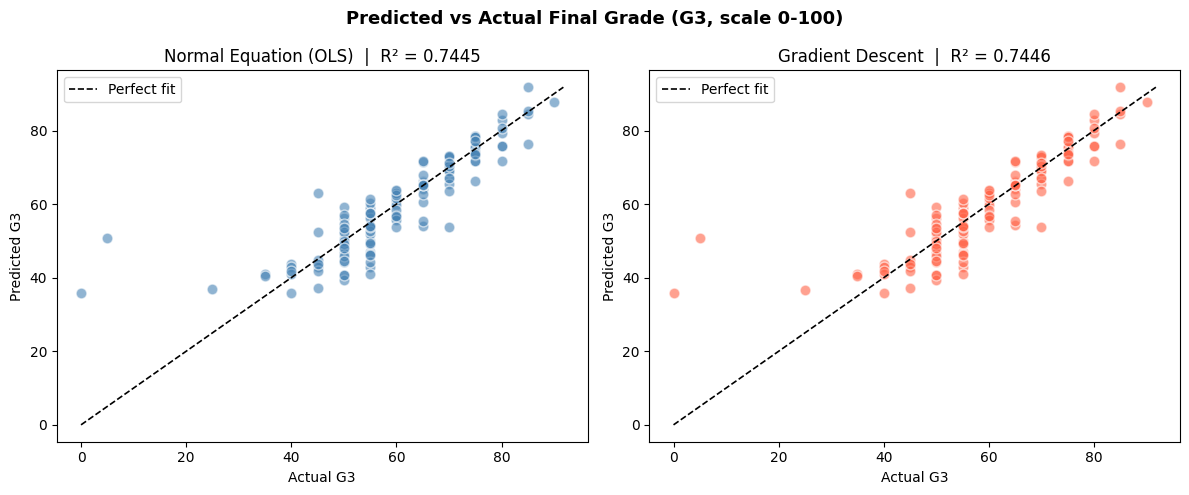

In [ ]:
plot_predictions(y_te, y_pred_ols, y_pred_gd)

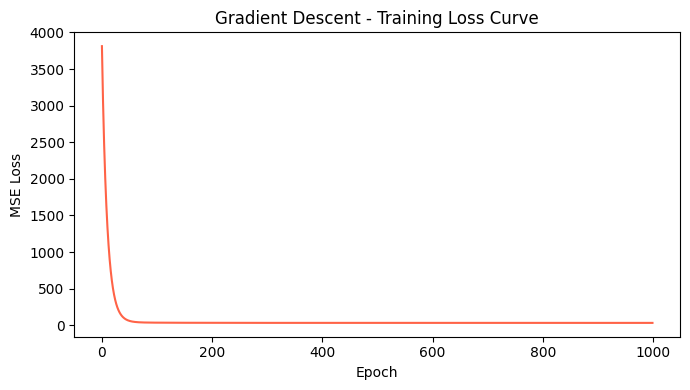

In [ ]:
plot_loss_curve(losses)

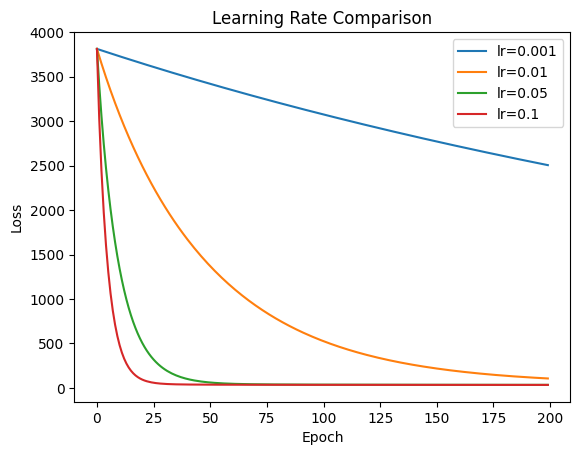

In [ ]:
lrs = [0.001, 0.01, 0.05, 0.1]
plot_learning_rates(X_tr_b, y_tr, lrs)

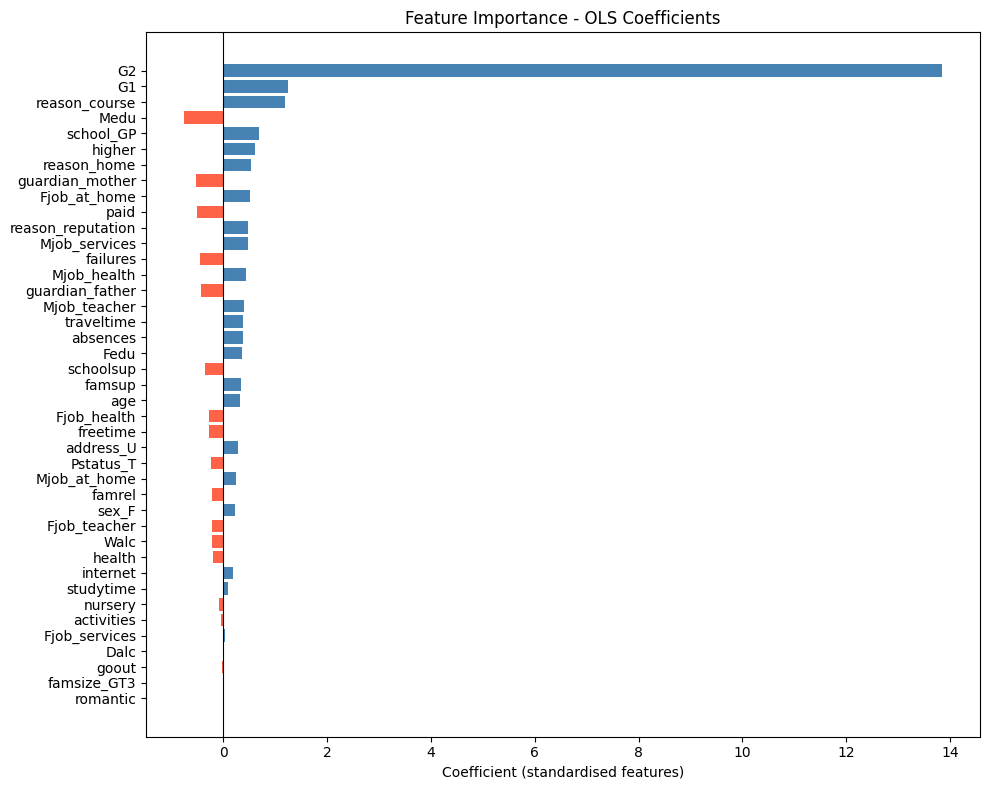

In [ ]:
plot_coefficients(w_ols, feature_names)

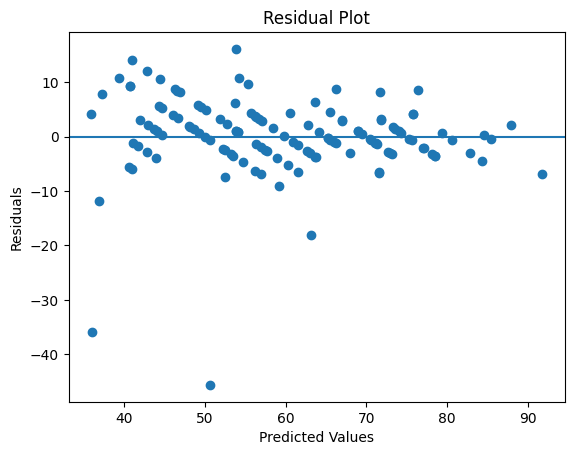

In [ ]:
plot_residuals(y_te, y_pred_ols)

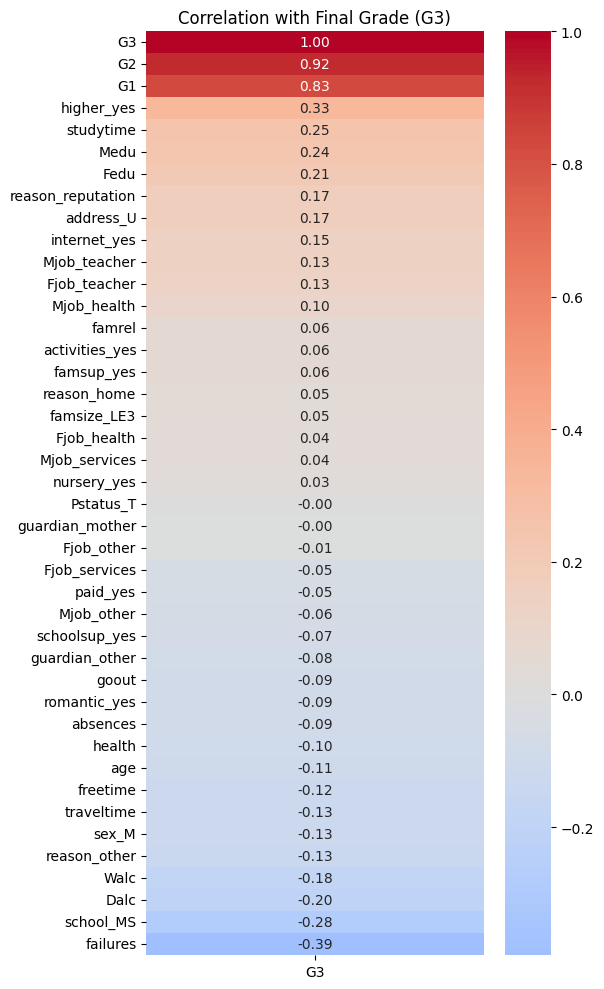

In [ ]:
plot_correlation_heatmap("student-por.csv")

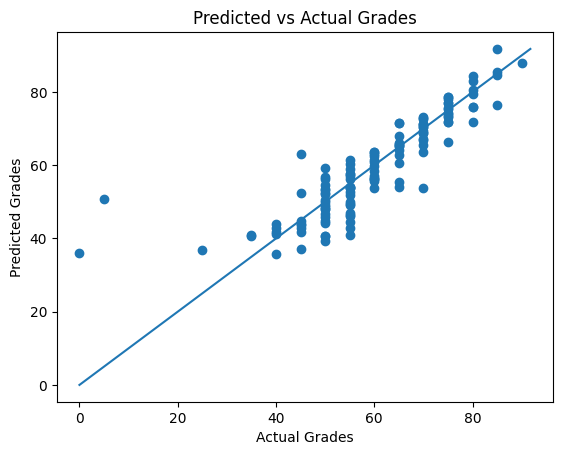

In [ ]:
plot_predicted_vs_actual(y_te, y_pred_ols)

## Conclusion

In this project, we used multiple linear regression techniques to predict student final grades (G3) without relying on G1 and G2. By excluding these highly correlated variables, we created a more challenging but meaningful prediction task.

The model achieved moderate accuracy, as shown by the MSE and R² values. Key factors such as study time and absences showed noticeable influence on student performance, while other variables had weaker effects. 

Additionally, ridge regression did not significantly alter performance, indicating that overfitting was not a major concern. Overall, this analysis demonstrates that student performance can be partially predicted using behavioral and background factors, though it remains a complex problem influenced by many variables.

## AI Usage

AI tools such as ChatGPT were used to assist with structuring the code, debugging, and refining written explanations. All modeling decisions, interpretations, and final edits were reviewed and understood by the group members.